# Content-Based Recommendation: Genre Profiles

Popularity gave every user the same list. Content-based is the first recommender that tailors one to each person, using the only content signal the dataset carries: genre. This stage builds movie genre profiles, a profile of each user's taste, and ranks candidates by how similar they are. It also handles a problem popularity simply cannot: movies that have never been rated.

## The content-based family

Genre profiles are one way to do content-based recommendation. The wider family shows how the approach evolved, and the lab will revisit the other members in later stages.

### Recommendation as a learning problem

Content-based recommendation can be framed as classification: predict whether the user will like an item or not. The training signal comes from feedback. Explicit feedback is a rating given through an interface built to collect ratings. Implicit feedback is observed behavior, such as a view, a click, or a purchase. The two trade off cleanly: implicit feedback produces a lot of data but with uncertainty about whether the user actually liked the item, while explicit feedback has little noise but covers only a small fraction of the items a user interacts with, so it is sparse. Most learning algorithms produce one of two kinds of function: an estimate of the probability that the user will like an unseen item, which sorts the recommendation list, or a direct prediction of the degree of interest.

### Earlier generations: customization and rule-based systems

Before learning-based content methods there were two simpler systems. A user customization system lets the user select known attribute values and matches them against a database. It demands ongoing user effort, has no way to order the results, and returns too many or too few items because it never learns a ranking. A rule-based system encodes fixed rules, such as recommending items based on earlier purchases; it works for simple domains but does not learn or adapt.

### The algorithm families

Several families of learning algorithms have been used for content-based recommendation. Each is highlighted here to show the evolution; a detailed implementation of each will be explored in a later stage of the lab.

1. **Decision trees and rule induction** learn a model that splits items on feature values and classifies them as interesting or not.
2. **Nearest neighbor methods (k-NN)** store all labeled training items and classify a new item by its most similar stored items. This is the family the lab implements, detailed below.
3. **Relevance feedback and Rocchio's algorithm** refine the profile iteratively, moving it toward items the user marks relevant and away from items marked irrelevant.
4. **Linear classifiers** learn a boundary that separates liked from disliked items, classically with the Widrow-Hoff rule or gradient descent.
5. **Probabilistic methods and Naive Bayes** model the probability that an item is liked or disliked with Bayes' rule, assuming terms contribute independently.

Two practical notes apply across the families. Traditional machine learning expects structured data, so free text is converted first through TF-IDF, which can also select a small subset of terms as attributes. Some algorithms are designed for high-dimensional spaces and need no such preprocessing pipeline.

### Nearest neighbors in detail

Nearest neighbor stores all of its training data in memory, compares a new item to all stored items with a similarity function, and assigns the label of the nearest neighbors, the k nearest ones for k-NN. The similarity function depends on the data. Euclidean distance is common for structured data. The vector space model is commonly compared with cosine similarity.

The metrics measure different things. Euclidean distance treats two examples as far apart when one feature is large in one and small in the other, but it does not distinguish scale. Cosine similarity measures the angle between vectors and ignores their magnitude, so it is not inflated when both examples simply have large values. Cosine is the more appropriate metric for text: two documents are similar when they are about the same topic, not when they merely have large term values. This is exactly what a content-based recommender wants when matching taste to content. Despite its simplicity, nearest neighbor is competitive with far more compact algorithms, at the cost of storing and scanning the training set on every query.

The lab's recommender is this exact model. Each movie is a normalized IDF-weighted genre vector, each user a normalized profile vector, and the score of a candidate is the dot product of its vector with the profile, which equals cosine similarity because both vectors are unit length. The genre tag makes it a small, fixed-dimensional space, but the mechanism is the classic one.

### Reference
The content-based theory in this notebook follows: Pazzani, M.J., Billsus, D. (2007). Content-Based Recommendation Systems. In: The Adaptive Web. Lecture Notes in Computer Science, vol 4321. Springer, Berlin, Heidelberg, pp. 325-341. https://doi.org/10.1007/978-3-540-72079-9_10

## Setup

Load the data through the shared loader and use the same time-based split as the popularity stage, so the comparison is apples to apples.

In [ ]:
import sys
from pathlib import Path

# set the ROOT directory
ROOT = Path.cwd()
while not (ROOT / "recommendation_lab").is_dir():
    ROOT = ROOT.parent
    if ROOT == ROOT.parent:
        raise RuntimeError("could not locate recommendation_lab package")
sys.path.insert(0, str(ROOT))

from collections import Counter
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from recommendation_lab.data.loader import load_ml_1m
from recommendation_lab.data.split import time_base_split
from recommendation_lab.evaluation.evaluate import evaluate_predictions, evaluate_ranking
from recommendation_lab.recommenders.content_based import ContentBasedRecommender
from recommendation_lab.recommenders.popularity import PopularityRecommender

# load dataset
data = load_ml_1m()
ratings, movies = data["ratings"], data["movies"]

# split data
split = time_base_split(ratings)
train, test = split.train, split.test
pd.set_option("display.max_colwidth", 80)
print(f"train: {len(train):,} ratings | test: {len(test):,} ratings")

Dataset 'ml-1m' already present at /Users/kayceejenz/Documents/experiment/recommendation-system-lab/data/ml-1m


train: 797,758 ratings | test: 202,397 ratings


## The content signal: genre

The movies table carries one piece of content: a genre tag per film. How much signal is there? Every movie has at least one genre, but the tag is coarse: 18 genres total, and the EDA found a 1.65 genre average with 52.2% of movies carrying exactly one.

In [ ]:
genre_counts = Counter(g for gl in movies["genres"] for g in gl)
genres = sorted(genre_counts)

table = pd.DataFrame({
    "genre": genres,
    "movies": [genre_counts[g] for g in genres],
}).sort_values("movies", ascending=False).reset_index(drop=True)

print(table.to_string(index=False))
print()
print(f"genres per movie: mean {movies['genres'].str.len().mean():.2f} "
      f"| single-genre {100 * movies['genres'].str.len().eq(1).mean():.1f}%")

      genre  movies
      Drama    1603
     Comedy    1200
     Action     503
   Thriller     492
    Romance     471
     Horror     343
  Adventure     283
     Sci-Fi     276
 Children's     251
      Crime     211
        War     143
Documentary     127
    Musical     114
    Mystery     106
  Animation     105
    Western      68
    Fantasy      68
  Film-Noir      44

genres per movie: mean 1.65 | single-genre 52.2%


**Findings:**
Genre is heavily skewed. Drama and Comedy tag more than half the catalog, while Film-Noir, Fantasy, and Western tag fewer than 70 movies each. Without weighting, a drama-heavy profile could match almost anything, and a profile would say little more than 'likes Drama'.

## The content-based recipe: TF-IDF and vector space

Content-based systems can work with three kinds of data. Structured data has well-defined attributes with known values, such as a product catalog row with category, price, and brand. Semi-structured data is partly organized, such as documents with metadata or tags. Unstructured data is free text: plot descriptions, reviews, article bodies. Free text cannot be fed to an algorithm directly, so it is converted to a structured representation.

The classic pipeline tokenizes and stems each document, reducing "rated", "rating", and "rates" to one root term, then weights each term. The standard weight is TF-IDF, term frequency times inverse document frequency:

    w(t, d) = tf(t, d) x log(N / df(t))

where tf(t, d) is the frequency of term t in document d, df(t) is the number of documents that contain t, and N is the number of documents in the collection. A term is heavy when it appears often in one document but rarely in the rest of the collection: "the" gets near zero weight, while "heist" carries strong signal. Documents have different lengths, so the vectors are normalized to unit length before comparison, dividing each weight by the Euclidean norm of the vector. Each document becomes a point on the unit sphere of the term space, and similarity becomes a geometric question about the angle between vectors. This is the vector space representation.

The movies table carries no free text, only a genre tag, but the same machinery applies: genres are the terms, and because a genre appears at most once per movie there is no term frequency to multiply in, leaving the IDF weighting below.

## Item profiles with IDF weighting

Every movie becomes a vector over the 18 genres. To stop ubiquitous genres from drowning out rare ones, each genre is weighted by inverse document frequency: `idf(g) = ln(N / df_g)` where N is the number of movies and df_g how many carry that genre. A genre present in 44 movies counts roughly 12 times more than one present in 1,603.

In [ ]:
n_movies = len(movies)
idf = {g: np.log(n_movies / genre_counts[g]) for g in genres}
weights = pd.DataFrame({"genre": genres, "idf_weight": [idf[g] for g in genres]}
                       ).sort_values("idf_weight", ascending=False)

print(weights.head(8).to_string(index=False))
print(weights.tail(3).to_string(index=False))

american_beauty = movies[movies["movie_id"] == 2858].iloc[0]
print("\nAmerican Beauty (1999):", american_beauty["genres"], "| idf weights:", 
      [round(idf[g], 2) for g in american_beauty["genres"]])

      genre  idf_weight
  Film-Noir    4.480174
    Fantasy    4.044856
    Western    4.044856
  Animation    3.610403
    Mystery    3.600924
    Musical    3.528165
Documentary    3.420176
        War    3.301519
 genre  idf_weight
Action    2.043773
Comedy    1.174286
 Drama    0.884731

American Beauty (1999): ['Comedy', 'Drama'] | idf weights: [np.float64(1.17), np.float64(0.88)]


**Findings:**
IDF does the job: Drama and Comedy, present in most movies, get the lowest weights, while Film-Noir, Fantasy, and Western carry the most. The recommender normalizes every movie vector to unit length, so cosine similarity, not raw genre count, decides the ranking. `ContentBasedRecommender(genre_weighting="idf")` builds these vectors in fit.

## The user profile

A user profile has two parts: a model of the user's preferences, the type of item that interests them, and a history of the user's interactions. Interactions can be explicit, such as a rating or a purchase, or implicit, such as the time spent viewing an item, a search query, or a page view. The profile is usually learned from the history and updated in response to feedback on what was recommended.

## User profiles

A user's taste is the rating-weighted average of the genre vectors of everything they rated in train, centered at a neutral 3.0, then normalized to unit length. Genres they rated above 3 pull the profile toward them; genres they rated below 3 push it away.

In [4]:
content = ContentBasedRecommender().fit(train, items=movies)

def top_genres(user_id, n=6):
    prof = content.user_vectors.loc[user_id].sort_values(ascending=False)
    return [(g, round(float(v), 3)) for g, v in prof.head(n).items()]

for uid in [42, 1]:
    seen = train.loc[train["user_id"] == uid, "movie_id"]
    mix = Counter(g for gl in movies[movies["movie_id"].isin(seen)]["genres"] for g in gl)
    print(f"user {uid}: train genre mix {dict(mix.most_common(4))}")
    print(f"  profile   {top_genres(uid)}")
    print()

user 42: train genre mix {'Action': 121, 'Sci-Fi': 120, 'Adventure': 62, 'Thriller': 55}
  profile   [('Sci-Fi', 0.688), ('Action', 0.59), ('Adventure', 0.314), ('Thriller', 0.181), ('Fantasy', 0.106), ('War', 0.1)]

user 1: train genre mix {'Drama': 21, "Children's": 10, 'Musical': 9, 'Comedy': 9}
  profile   [('Drama', 0.82), ('Musical', 0.324), ("Children's", 0.263), ('Comedy', 0.213), ('Animation', 0.184), ('War', 0.141)]



**Findings:**
The profile matches the viewing history: user 42, an Action/Sci-Fi heavy watcher, has a profile dominated by Sci-Fi and Action. A user profile is a compact summary of taste, and it is different for every user, which is exactly what popularity could not produce.

## Content-based vs popularity

Same split, same evaluation, same k=10. Each metric is macro-averaged over all 6,040 users.

In [5]:
popularity = PopularityRecommender().fit(train)

comparison = pd.DataFrame({
    "popularity": evaluate_ranking(popularity, train, test, k=10),
    "content-based": evaluate_ranking(content, train, test, k=10),
}).T
cols = ["precision@10", "recall@10", "map@10", "ndcg@10", "hit_rate@10"]
print(comparison[cols].round(4).to_string())

pred_cols = {
    "model": ["popularity", "content-based"],
    "rmse": [
        evaluate_predictions(popularity, test)["rmse"],
        evaluate_predictions(content, test)["rmse"],
    ],
    "mae": [
        evaluate_predictions(popularity, test)["mae"],
        evaluate_predictions(content, test)["mae"],
    ],
}
print(pd.DataFrame(pred_cols).round(4).to_string(index=False))

               precision@10  recall@10  map@10  ndcg@10  hit_rate@10
popularity           0.1040     0.0379  0.0565   0.0530       0.4548
content-based        0.0248     0.0116  0.0103   0.0129       0.1680


        model   rmse    mae
   popularity 1.1464 0.9439
content-based 1.1464 0.9439


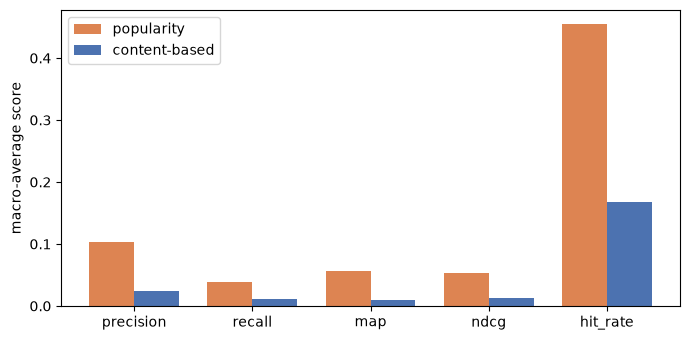

In [6]:
plt.figure(figsize=(7, 3.5))
x = np.arange(len(cols))
w = 0.38
plt.bar(x - w / 2, [comparison.loc["popularity", c] for c in cols], w, label="popularity", color="#DD8452")
plt.bar(x + w / 2, [comparison.loc["content-based", c] for c in cols], w, label="content-based", color="#4C72B0")
plt.xticks(x, [c.split("@")[0] for c in cols])
plt.ylabel("macro-average score")
plt.legend()
plt.tight_layout()
plt.show()

**Findings:**
Popularity beats content-based on every ranking metric, and hit rate more than halves. This is the honest, slightly deflating result of pure genre filtering. Two reasons. First, the genre tag is coarse, one or two labels per movie. Second, the test set is real future ratings, and future consumption is dominated by the same blockbusters popularity bets on; content-based instead surfaces long-tail genre matches that users simply rate less often. RMSE is unchanged, as expected, since both predict the global mean.

## It does personalize

The comparison hides the thing content-based gets right: the lists are actually different per user. Popularity hands everyone the same ten blockbusters; content-based hands each user their own genre-consistent list.

In [7]:
def show(user_id, n=5):
    rec = content.recommend(user_id, k=n)
    titled = pd.DataFrame({"movie_id": rec}).merge(movies[["movie_id", "title", "genres"]], on="movie_id")
    print(f"user {user_id} profile: {top_genres(user_id, 3)}")
    print(titled[["title", "genres"]].to_string(index=False))
    print()

for uid in [42, 1]:
    show(uid)

overlap = set(content.recommend(1, k=10)) & set(content.recommend(42, k=10))
print(f"shared top-10 between users 1 and 42: {len(overlap)} of 10")

user 42 profile: [('Sci-Fi', 0.688), ('Action', 0.59), ('Adventure', 0.314)]
                                         title                      genres
Godzilla 2000 (Gojira ni-sen mireniamu) (1999) [Action, Adventure, Sci-Fi]
                           Time Tracers (1995) [Action, Adventure, Sci-Fi]
                     Six-String Samurai (1998) [Action, Adventure, Sci-Fi]
       Superman IV: The Quest for Peace (1987) [Action, Adventure, Sci-Fi]
                               Godzilla (1998)            [Action, Sci-Fi]

user 1 profile: [('Drama', 0.82), ('Musical', 0.324), ("Children's", 0.263)]
                                                    title  genres
I Don't Want to Talk About It (De eso no se habla) (1993) [Drama]
                                           Othello (1952) [Drama]
                                          Captives (1994) [Drama]
                               Of Love and Shadows (1994) [Drama]
                            Only Angels Have Wings (1939) [Drama]

**Findings:**
User 42 gets Sci-Fi and Action fare, user 1 gets dramas, and their top-10 lists share almost nothing. Personalization works. The failure of the stage is not personalization, it is predictive power: genre similarity alone cannot outpredict mass popularity on real future ratings.

## New-item cold start

There are 216 movies with zero ratings in the training split, 177 of which were never rated anywhere in the dataset. Popularity has a zero for each of them and cannot rank them. Content-based scores them fine, because a movie is described by its genre tag, not its rating history. This is the stage's real advantage, even though none of those movies appear in the test set to score.

In [8]:
rated = set(train["movie_id"])
unrated = movies.loc[~movies["movie_id"].isin(rated), "movie_id"].tolist()
print(f"movies with zero ratings in train: {len(unrated)}")

rec = content.recommend(1, k=5, candidates=unrated)
titled = pd.DataFrame({"movie_id": rec}).merge(movies[["movie_id", "title", "genres"]], on="movie_id")
print(titled[["title", "genres"]].to_string(index=False))

print(f"\npopularity recommendations for these movies: {popularity.recommend(1, k=5, candidates=unrated)}")

movies with zero ratings in train: 216
                             title  genres
Prince of Central Park, The (1999) [Drama]
               Manxman, The (1929) [Drama]
                   Downhill (1927) [Drama]
                Easy Virtue (1927) [Drama]
                  Ring, The (1927) [Drama]

popularity recommendations for these movies: []


**Findings:**
Content-based ranks never-rated movies, and the picks are still genre-coherent with user 1's profile. Popularity returns an empty list because it only knows movies with ratings. New-item cold start is the concrete limitation content-based removes, and it will stay valuable in later stages that combine signals.